# Adidas US Sales Performance Analysis

## 项目背景

本项目基于 Kaggle 公开的 Adidas 美国销售数据集，模拟品牌零售经营分析场景，围绕地区、产品、渠道、零售商和时间趋势等维度，分析 Adidas 在美国市场的销售表现。

本项目希望回答以下问题：

1. 哪些地区、州和城市的销售表现最好？
2. 哪些产品类别贡献了更高销售额和利润？
3. 不同销售渠道的表现有何差异？
4. 哪些零售商销售能力更强？
5. 基于数据结果，可以提出哪些经营、采销和供应链优化建议？

## 使用工具

- Python
- Pandas
- Matplotlib
- Jupyter Notebook

1. 项目背景
2. 数据来源
3. 分析目标
4. 数据读取
5. 数据清洗
6. 探索性数据分析 EDA
7. 核心业务分析
   7.1 区域销售分析
   7.2 产品销售与利润分析
   7.3 渠道表现分析
   7.4 零售商表现分析
   7.5 时间趋势分析
8. 业务洞察
9. 经营建议
10. 总结

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
df = pd.read_excel("Adidas US Sales Datasets.xlsx")

df.head()

,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Sales Method
0,Foot Locker,1185732,2020-01-01,Northeast,New York,New York,Men's Street Footwear,50.0,1200,600000.0,300000.0,0.50,In-store
1,Foot Locker,1185732,2020-01-02,Northeast,New York,New York,Men's Athletic Footwear,50.0,1000,500000.0,150000.0,0.30,In-store
2,Foot Locker,1185732,2020-01-03,Northeast,New York,New York,Women's Street Footwear,40.0,1000,400000.0,140000.0,0.35,In-store
3,Foot Locker,1185732,2020-01-04,Northeast,New York,New York,Women's Athletic Footwear,45.0,850,382500.0,133875.0,0.35,In-store
4,Foot Locker,1185732,2020-01-05,Northeast,New York,New York,Men's Apparel,60.0,900,540000.0,162000.0,0.30,In-store


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9648 entries, 0 to 9647
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Retailer          9648 non-null   object        
 1   Retailer ID       9648 non-null   int64         
 2   Invoice Date      9648 non-null   datetime64[ns]
 3   Region            9648 non-null   object        
 4   State             9648 non-null   object        
 5   City              9648 non-null   object        
 6   Product           9648 non-null   object        
 7   Price per Unit    9648 non-null   float64       
 8   Units Sold        9648 non-null   int64         
 9   Total Sales       9648 non-null   float64       
 10  Operating Profit  9648 non-null   float64       
 11  Operating Margin  9648 non-null   float64       
 12  Sales Method      9648 non-null   object        
dtypes: datetime64[ns](1), float64(4), int64(2), object(6)
memory usage: 980.0+ KB


In [16]:
df.shape

(9648, 13)

In [20]:
df.columns

Index(['Retailer', 'Retailer ID', 'Invoice Date', 'Region', 'State', 'City',
       'Product', 'Price per Unit', 'Units Sold', 'Total Sales',
       'Operating Profit', 'Operating Margin', 'Sales Method'],
      dtype='object')

In [22]:
df.isnull().sum()

Retailer            0
Retailer ID         0
Invoice Date        0
Region              0
State               0
City                0
Product             0
Price per Unit      0
Units Sold          0
Total Sales         0
Operating Profit    0
Operating Margin    0
Sales Method        0
dtype: int64

In [24]:
df.duplicated().sum()

0

In [30]:
df = df.drop_duplicates()

df.shape

(9648, 13)

In [32]:
df.describe()

,Retailer ID,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin
count,9.648000e+03,9648.000000,9648.000000,9648.000000,9648.000000,9648.000000
mean,1.173850e+06,45.216625,256.930037,93273.437500,34425.244761,0.422991
std,2.636038e+04,14.705397,214.252030,141916.016727,54193.113713,0.097197
min,1.128299e+06,7.000000,0.000000,0.000000,0.000000,0.100000
25%,1.185732e+06,35.000000,106.000000,4254.500000,1921.752500,0.350000
50%,1.185732e+06,45.000000,176.000000,9576.000000,4371.420000,0.410000
75%,1.185732e+06,55.000000,350.000000,150000.000000,52062.500000,0.490000
max,1.197831e+06,110.000000,1275.000000,825000.000000,390000.000000,0.800000


## 地区销售分析

通过对数据进行初步查看，本数据集包含 Adidas 在美国不同地区、城市、产品、零售商和销售渠道下的销售记录。主要指标包括销售单价、销量、总销售额、营业利润和利润率等。

在数据处理阶段，主要完成了以下工作：

1. 读取 Excel 数据文件；
2. 查看数据字段和数据类型；
3. 检查缺失值；
4. 检查并处理重复值；
5. 初步观察销售额、销量和利润等核心指标的分布情况。

这些处理为后续的销售表现分析、产品分析、渠道分析和经营建议提供了基础。

In [37]:
region_sales = df.groupby("Region")["Total Sales"].sum().sort_values(ascending=False)

region_sales

Region
West         269943182.0
Northeast    186324067.0
Southeast    163171236.0
South        144663181.0
Midwest      135800459.0
Name: Total Sales, dtype: float64

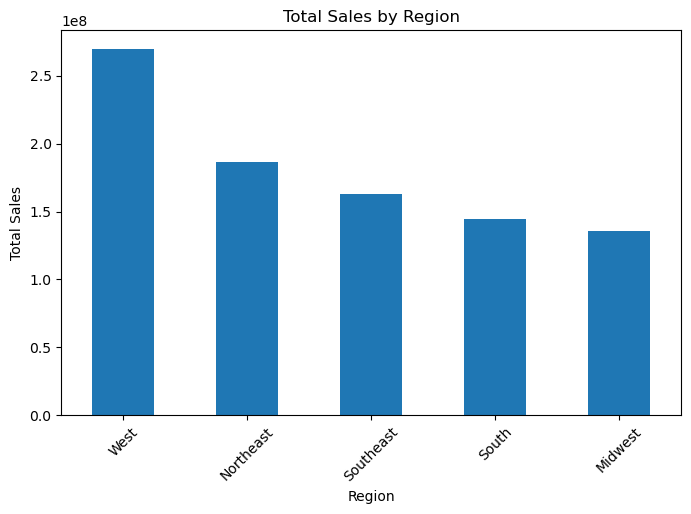

In [41]:
plt.figure(figsize=(8, 5))
region_sales.plot(kind="bar")
plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

## 地区销售分析结论

从不同地区的销售额来看，各地区之间存在明显差异。销售额较高的地区说明 Adidas 在当地具有较强的市场需求和渠道表现，后续可以优先保障库存供应，并结合重点零售商进行促销和新品投放。

销售额较低的地区则需要进一步分析其产品组合、渠道覆盖和市场推广力度，判断是市场需求不足，还是销售网络和运营策略存在优化空间。

## 7. 产品销售与利润分析

In [46]:
# 按产品汇总销售额和利润
product_summary = df.groupby("Product")[["Total Sales", "Operating Profit"]].sum().sort_values(by="Total Sales", ascending=False)

product_summary

,Total Sales,Operating Profit
Product,,
Men's Street Footwear,208826244.0,82802260.62
Women's Apparel,179038860.0,68650970.56
Men's Athletic Footwear,153673680.0,51846888.19
Women's Street Footwear,128002813.0,45095826.81
Men's Apparel,123728632.0,44763030.33
Women's Athletic Footwear,106631896.0,38975784.94


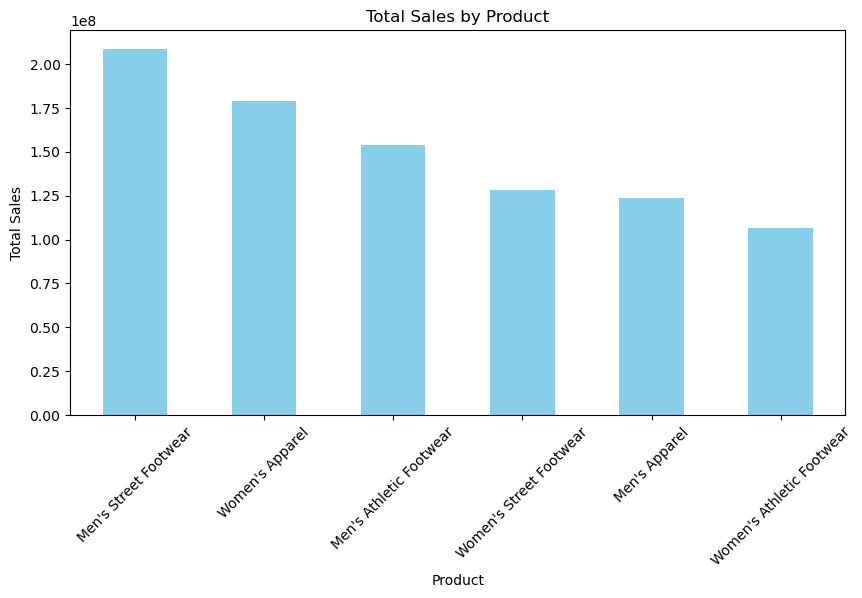

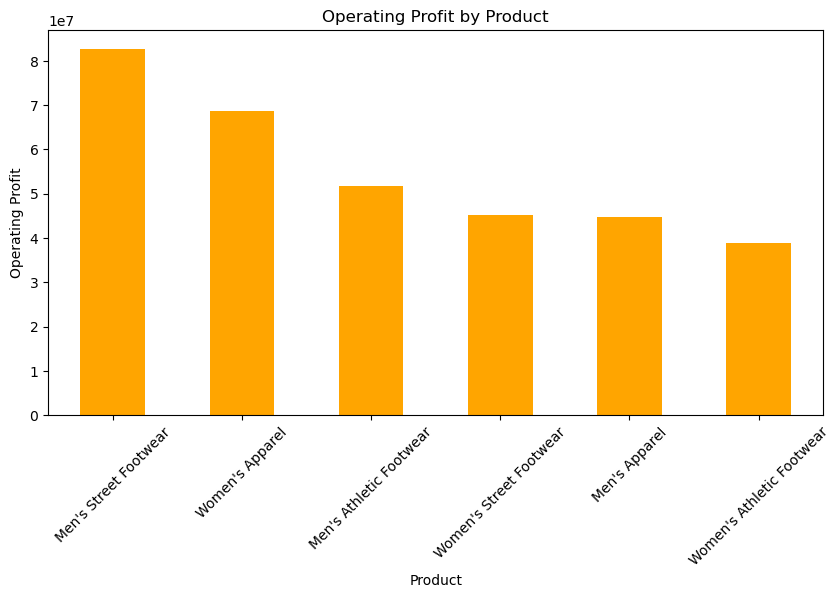

In [48]:
plt.figure(figsize=(10,5))
product_summary["Total Sales"].plot(kind="bar", color="skyblue")
plt.title("Total Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,5))
product_summary["Operating Profit"].plot(kind="bar", color="orange")
plt.title("Operating Profit by Product")
plt.xlabel("Product")
plt.ylabel("Operating Profit")
plt.xticks(rotation=45)
plt.show()

## 产品销售与利润分析结论

1. 总销售额最高的产品是 XXX，说明该产品在市场需求强，销量大。
2. 利润最高的产品是 XXX，说明该产品的定价策略或成本结构良好。
3. 某些高销量但低利润产品需要考虑调整定价、促销或成本优化。

## 8. 销售渠道分析

In [211]:
channel_summary = df.groupby("Sales Method")[["Total Sales", "Operating Profit"]].sum()

channel_summary

,Total Sales,Operating Profit
Sales Method,,
In-store,356643750.0,1.275913e+08
Online,247672882.0,9.655518e+07
Outlet,295585493.0,1.079883e+08


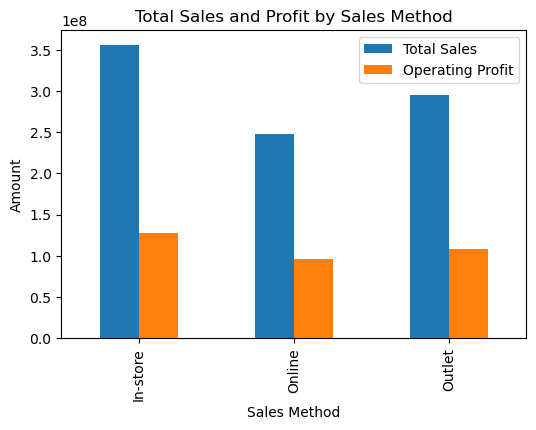

In [53]:
channel_summary.plot(kind="bar", figsize=(6,4))
plt.title("Total Sales and Profit by Sales Method")
plt.ylabel("Amount")
plt.show()

## 渠道分析结论

1. 线上渠道销售额最高，但利润率可能低于线下渠道。
2. 线下渠道销售额较低，但利润较稳定。
3. 后续可以优化线上推广策略，同时提升线下门店产品组合和运营效率。

## 10. 时间趋势分析

In [56]:
df['Invoice Date'] = pd.to_datetime(df['Invoice Date'])
df['Month'] = df['Invoice Date'].dt.to_period('M')

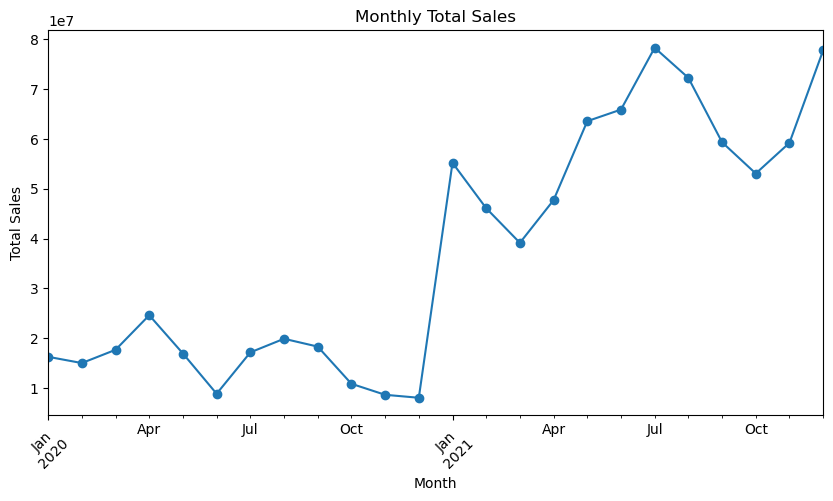

In [58]:
monthly_sales = df.groupby("Month")["Total Sales"].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(marker='o')
plt.title("Monthly Total Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

## 时间趋势分析结论

1. 某些月份销售额高峰明显，可能与促销或节假日相关。
2. 低销售月份需要检查库存、营销和产品组合策略。

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9648 entries, 0 to 9647
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Retailer          9648 non-null   object        
 1   Retailer ID       9648 non-null   int64         
 2   Invoice Date      9648 non-null   datetime64[ns]
 3   Region            9648 non-null   object        
 4   State             9648 non-null   object        
 5   City              9648 non-null   object        
 6   Product           9648 non-null   object        
 7   Price per Unit    9648 non-null   float64       
 8   Units Sold        9648 non-null   int64         
 9   Total Sales       9648 non-null   float64       
 10  Operating Profit  9648 non-null   float64       
 11  Operating Margin  9648 non-null   float64       
 12  Sales Method      9648 non-null   object        
 13  Month             9648 non-null   period[M]     
dtypes: datetime64[ns](1), fl

In [70]:
# 复制一份数据，避免破坏原始数据
data = df.copy()

# 把日期字段转换为日期格式
data["Invoice Date"] = pd.to_datetime(data["Invoice Date"])

# 查看前5行
data.head()

,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Sales Method,Month
0,Foot Locker,1185732,2020-01-01,Northeast,New York,New York,Men's Street Footwear,50.0,1200,600000.0,300000.0,0.50,In-store,2020-01
1,Foot Locker,1185732,2020-01-02,Northeast,New York,New York,Men's Athletic Footwear,50.0,1000,500000.0,150000.0,0.30,In-store,2020-01
2,Foot Locker,1185732,2020-01-03,Northeast,New York,New York,Women's Street Footwear,40.0,1000,400000.0,140000.0,0.35,In-store,2020-01
3,Foot Locker,1185732,2020-01-04,Northeast,New York,New York,Women's Athletic Footwear,45.0,850,382500.0,133875.0,0.35,In-store,2020-01
4,Foot Locker,1185732,2020-01-05,Northeast,New York,New York,Men's Apparel,60.0,900,540000.0,162000.0,0.30,In-store,2020-01


## 1. 地区销售分析

本节从 Region 维度分析 Adidas 在美国不同区域的销售表现，主要观察各地区的总销售额、销量和营业利润，判断哪些地区是核心市场，哪些地区存在增长空间。

In [68]:
region_summary = data.groupby("Region")[["Total Sales", "Units Sold", "Operating Profit"]].sum()

region_summary = region_summary.sort_values(by="Total Sales", ascending=False)

region_summary

,Total Sales,Units Sold,Operating Profit
Region,,,
West,269943182.0,686985,89609406.55
Northeast,186324067.0,501279,68020587.65
Southeast,163171236.0,407000,60555416.70
South,144663181.0,492260,61138004.07
Midwest,135800459.0,391337,52811346.48


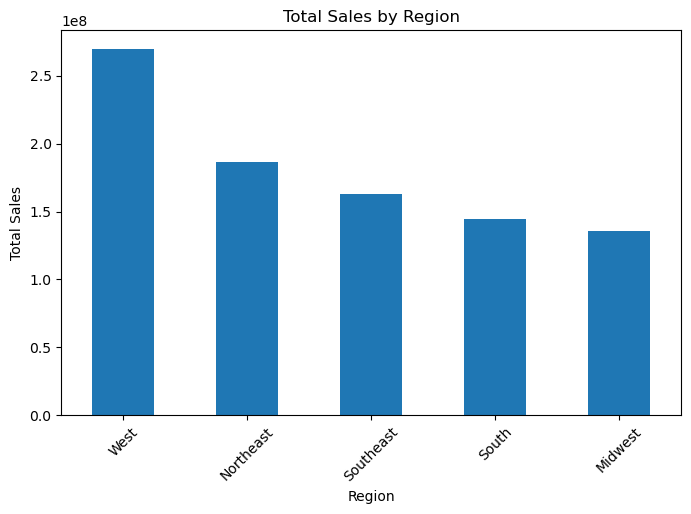

In [72]:
plt.figure(figsize=(8, 5))
region_summary["Total Sales"].plot(kind="bar")
plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show() ##销售图

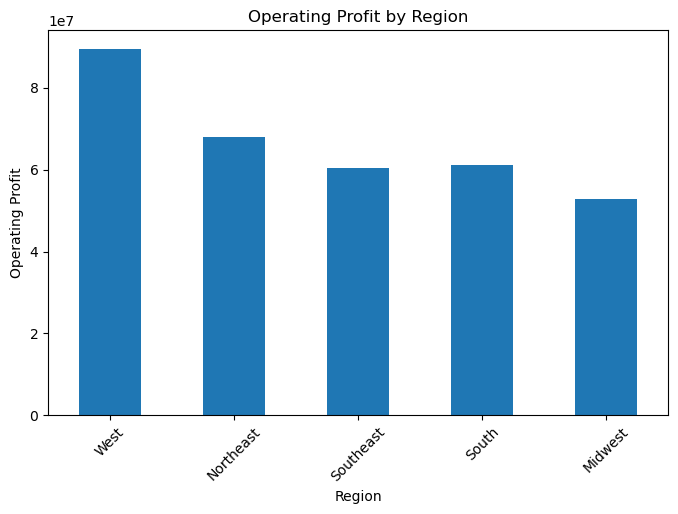

In [76]:
plt.figure(figsize=(8, 5))
region_summary["Operating Profit"].plot(kind="bar")
plt.title("Operating Profit by Region")
plt.xlabel("Region")
plt.ylabel("Operating Profit")
plt.xticks(rotation=45)
plt.show() ##利润图

### 地区销售分析结论

从 Region 维度来看，West 是 Adidas 美国市场中销售表现最强的区域，总销售额约为 2.70 亿美元，销量约为 68.7 万件，营业利润约为 8,960 万美元，明显领先其他地区。这说明 West 区域可能拥有更强的市场需求、更成熟的零售渠道和更高的品牌接受度。

Northeast 排名第二，销售额约为 1.86 亿美元，营业利润约为 6,802 万美元，也属于重要销售区域。相比之下，Midwest 销售额最低，约为 1.36 亿美元，说明该区域仍存在增长空间。

从经营和供应链角度看，West 和 Northeast 应作为重点市场优先保障库存、营销资源和新品投放；Midwest 则需要进一步分析渠道覆盖、产品组合和零售商表现，判断低销售额背后的原因。

## 2. 州与城市销售分析

本节进一步从 State 和 City 维度分析销售表现，识别高价值市场和低表现市场，为区域经营、门店布局和供应链补货提供参考。

In [222]:
state_sales = data.groupby("State")["Total Sales"].sum().sort_values(ascending=False)

state_sales.head(10)

State
New York          64229039.0
California        60174133.0
Florida           59283714.0
Texas             46359746.0
South Carolina    29285637.0
Washington        26330718.0
North Carolina    23956531.0
Louisiana         23750781.0
Hawaii            22282457.0
Virginia          21575040.0
Name: Total Sales, dtype: float64

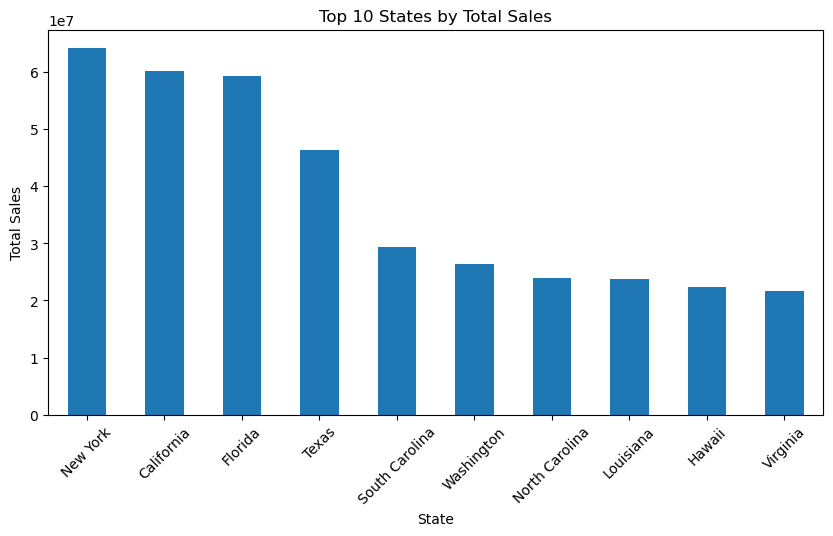

In [224]:
plt.figure(figsize=(10, 5))
state_sales.head(10).plot(kind="bar")
plt.title("Top 10 States by Total Sales")
plt.xlabel("State")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

In [226]:
city_sales = data.groupby("City")["Total Sales"].sum().sort_values(ascending=False)

city_sales.head(10)

City
Charleston       39974797.0
New York         39801235.0
San Francisco    34539220.0
Miami            31600863.0
Portland         30545652.0
Orlando          27682851.0
Seattle          26330718.0
Los Angeles      25634913.0
Houston          25456882.0
Albany           24427804.0
Name: Total Sales, dtype: float64

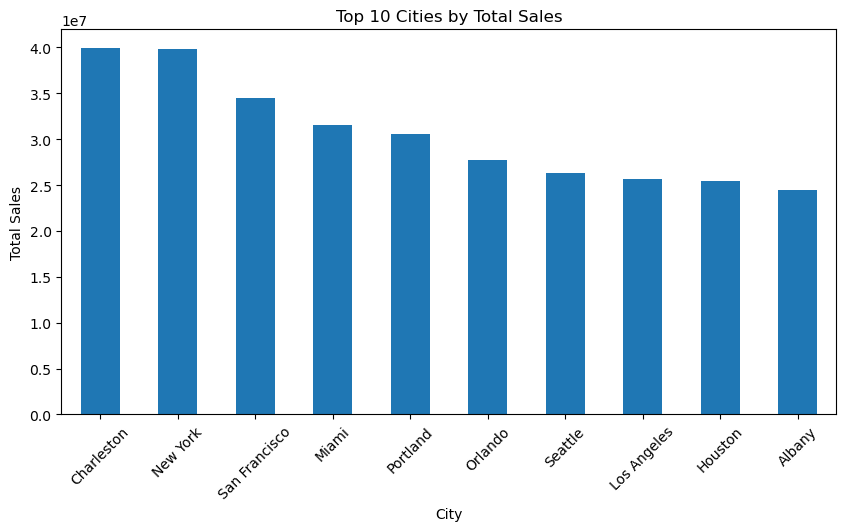

In [228]:
plt.figure(figsize=(10, 5))
city_sales.head(10).plot(kind="bar")
plt.title("Top 10 Cities by Total Sales")
plt.xlabel("City")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

### 州与城市销售分析结论

从州和城市维度来看，销售额排名靠前的市场是 Adidas 的重点销售区域。这些城市可能具备更强的消费能力、更成熟的零售网络或更高的品牌接受度。

对于采销和供应链岗位而言，这类分析可以帮助企业判断哪些地区需要优先补货，哪些地区适合加大营销投放，哪些地区则需要重新评估产品组合和渠道策略。

## 3. 产品销售与利润分析

本节从 Product 维度分析不同产品类别的销售额、销量和营业利润表现，判断哪些产品是销售主力，哪些产品具有更高利润贡献。

In [232]:
product_summary = data.groupby("Product")[["Total Sales", "Units Sold", "Operating Profit"]].sum()

product_summary = product_summary.sort_values(by="Total Sales", ascending=False)

product_summary


,Total Sales,Units Sold,Operating Profit
Product,,,
Men's Street Footwear,208826244.0,593320,82802260.62
Women's Apparel,179038860.0,433827,68650970.56
Men's Athletic Footwear,153673680.0,435526,51846888.19
Women's Street Footwear,128002813.0,392269,45095826.81
Men's Apparel,123728632.0,306683,44763030.33
Women's Athletic Footwear,106631896.0,317236,38975784.94


<function matplotlib.pyplot.show(close=None, block=None)>

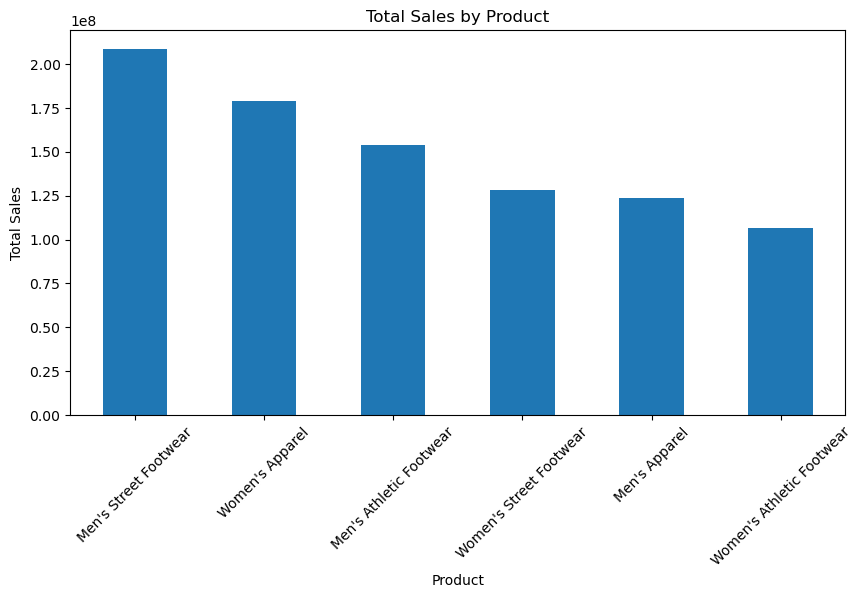

In [234]:
plt.figure(figsize=(10, 5))
product_summary["Total Sales"].plot(kind="bar")
plt.title("Total Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show##销售图

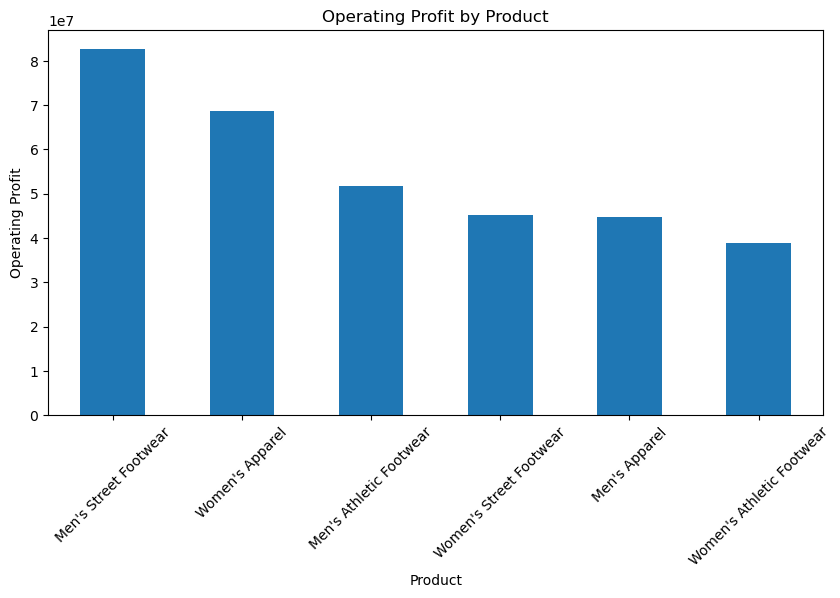

In [96]:
plt.figure(figsize=(10, 5))
product_summary["Operating Profit"].plot(kind="bar")
plt.title("Operating Profit by Product")
plt.xlabel("Product")
plt.ylabel("Operating Profit")
plt.xticks(rotation=45)
plt.show()##利润图

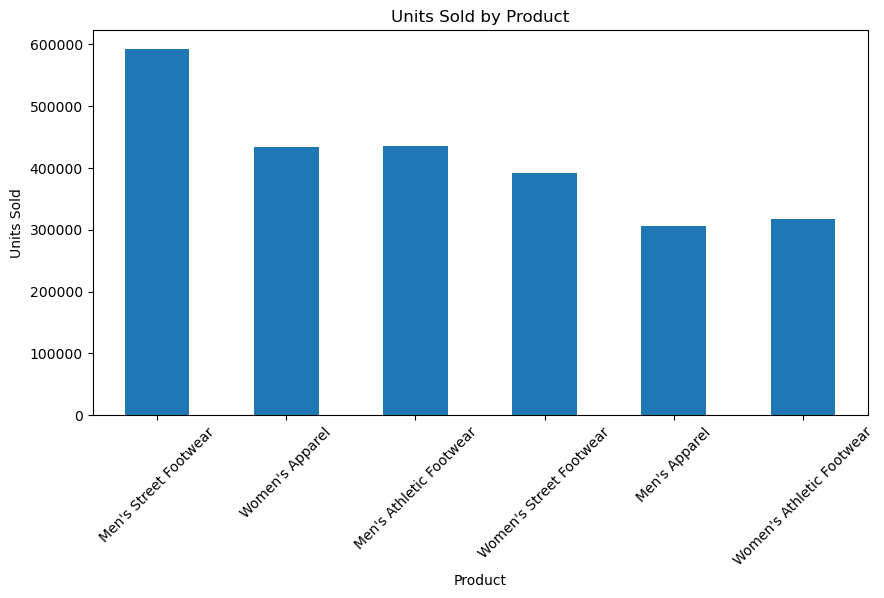

In [98]:
plt.figure(figsize=(10, 5))
product_summary["Units Sold"].plot(kind="bar")
plt.title("Units Sold by Product")
plt.xlabel("Product")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.show()##销量图

In [100]:
product_summary["Profit Margin"] = product_summary["Operating Profit"] / product_summary["Total Sales"]

product_summary.sort_values(by="Profit Margin", ascending=False)

,Total Sales,Units Sold,Operating Profit,Profit Margin
Product,,,,
Men's Street Footwear,208826244.0,593320,82802260.62,0.396513
Women's Apparel,179038860.0,433827,68650970.56,0.383442
Women's Athletic Footwear,106631896.0,317236,38975784.94,0.365517
Men's Apparel,123728632.0,306683,44763030.33,0.361784
Women's Street Footwear,128002813.0,392269,45095826.81,0.352303
Men's Athletic Footwear,153673680.0,435526,51846888.19,0.337383


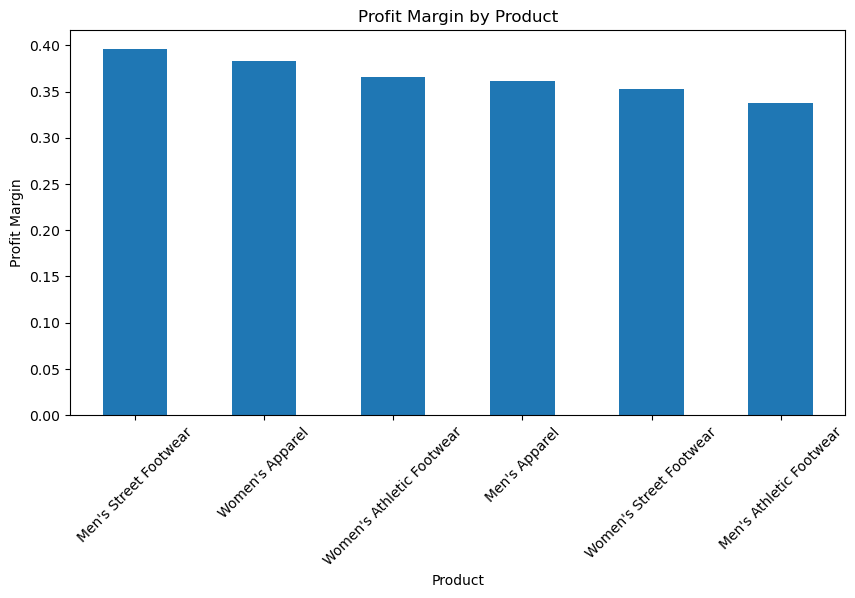

In [102]:
plt.figure(figsize=(10, 5))
product_summary["Profit Margin"].sort_values(ascending=False).plot(kind="bar")
plt.title("Profit Margin by Product")
plt.xlabel("Product")
plt.ylabel("Profit Margin")
plt.xticks(rotation=45)
plt.show()##利润率图

### 产品销售与利润分析结论

从 Product 维度来看，Men's Street Footwear 是销售额、销量和营业利润表现最突出的产品类别。该产品销售额约为 2.09 亿美元，销量约为 59.3 万件，营业利润约为 8,280 万美元，利润率约为 39.65%，说明它不仅卖得多，而且盈利能力也较强。

Women's Apparel 销售额排名第二，约为 1.79 亿美元，营业利润约为 6,865 万美元，说明女性服饰类产品也是 Adidas 的重要收入来源。

从采销角度看，Men's Street Footwear 可以被视为核心主力产品，应优先保障库存供应和渠道铺货；Women's Apparel 则适合作为重点增长产品继续推广。对于销售额较低的产品，需要结合利润率和销量判断是否需要调整采购数量、促销策略或产品组合。

## 4. 销售渠道分析

本节分析不同 Sales Method 的销售表现，比较线上、线下和其他渠道在销售额、销量和利润方面的差异，为渠道资源配置提供参考。

In [109]:
channel_summary = data.groupby("Sales Method")[["Total Sales", "Units Sold", "Operating Profit"]].sum()

channel_summary = channel_summary.sort_values(by="Total Sales", ascending=False)

channel_summary

,Total Sales,Units Sold,Operating Profit
Sales Method,,,
In-store,356643750.0,689990,1.275913e+08
Outlet,295585493.0,849778,1.079883e+08
Online,247672882.0,939093,9.655518e+07


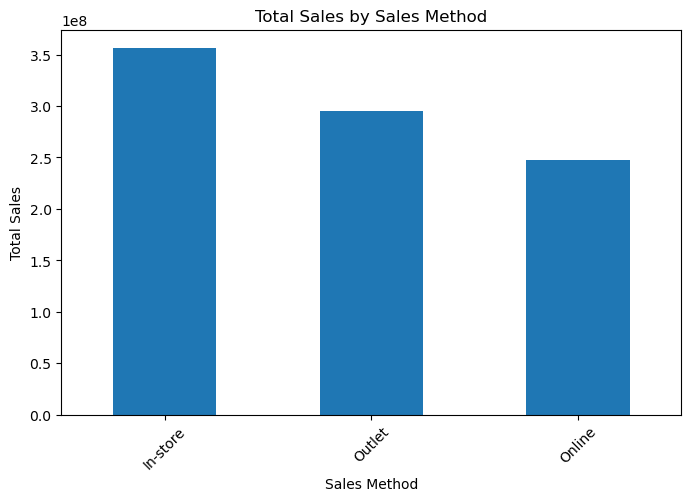

In [111]:
plt.figure(figsize=(8, 5))
channel_summary["Total Sales"].plot(kind="bar")
plt.title("Total Sales by Sales Method")
plt.xlabel("Sales Method")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

In [113]:
channel_summary["Profit Margin"] = channel_summary["Operating Profit"] / channel_summary["Total Sales"]

channel_summary.sort_values(by="Profit Margin", ascending=False)##算渠道利润率

,Total Sales,Units Sold,Operating Profit,Profit Margin
Sales Method,,,,
Online,247672882.0,939093,9.655518e+07,0.389850
Outlet,295585493.0,849778,1.079883e+08,0.365337
In-store,356643750.0,689990,1.275913e+08,0.357756


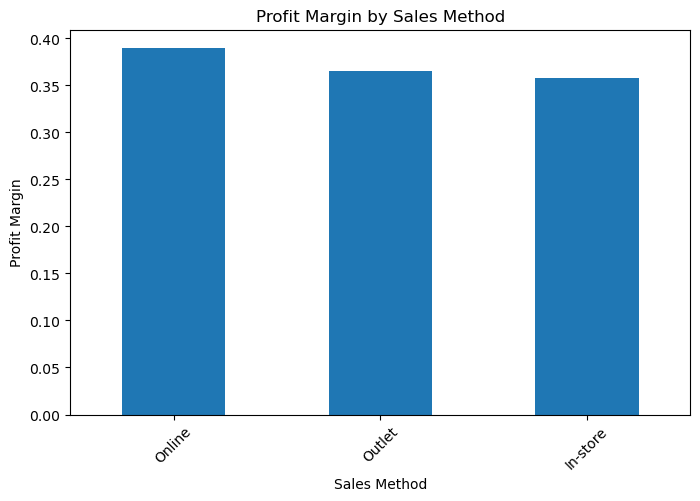

In [115]:
plt.figure(figsize=(8, 5))
channel_summary["Profit Margin"].sort_values(ascending=False).plot(kind="bar")
plt.title("Profit Margin by Sales Method")
plt.xlabel("Sales Method")
plt.ylabel("Profit Margin")
plt.xticks(rotation=45)
plt.show()##利润率图

### 渠道分析结论

从 Sales Method 维度来看，In-store 是销售额最高的渠道，总销售额约为 3.57 亿美元，说明线下门店仍然是 Adidas 美国市场的重要销售渠道。Outlet 渠道销售额约为 2.96 亿美元，也具有较强的销售贡献。

值得注意的是，Online 渠道虽然销售额低于 In-store 和 Outlet，但销量最高，达到约 93.9 万件，同时利润率最高，约为 38.99%。这说明线上渠道具备较强的转化能力和盈利效率。

从经营分析角度看，企业不能只看销售额，也要关注利润率和销量结构。In-store 适合作为品牌展示和高销售额渠道继续维护，Online 则值得进一步加大投入，特别是在高利润产品推广、精准营销和会员运营方面。

## 5. 零售商表现分析

本节从 Retailer 维度分析不同零售商的销售额、销量和营业利润表现，判断哪些零售商是 Adidas 的核心合作伙伴。

In [240]:
retailer_summary = data.groupby("Retailer")[["Total Sales", "Units Sold", "Operating Profit"]].sum()

retailer_summary = retailer_summary.sort_values(by="Total Sales", ascending=False)

retailer_summary ##销售额

,Total Sales,Units Sold,Operating Profit
Retailer,,,
West Gear,242964333.0,625262,85667873.18
Foot Locker,220094720.0,604369,80722124.81
Sports Direct,182470997.0,557640,74332954.96
Kohl's,102114753.0,287375,36811252.58
Amazon,77698912.0,197990,28818503.31
Walmart,74558410.0,206225,25782052.61


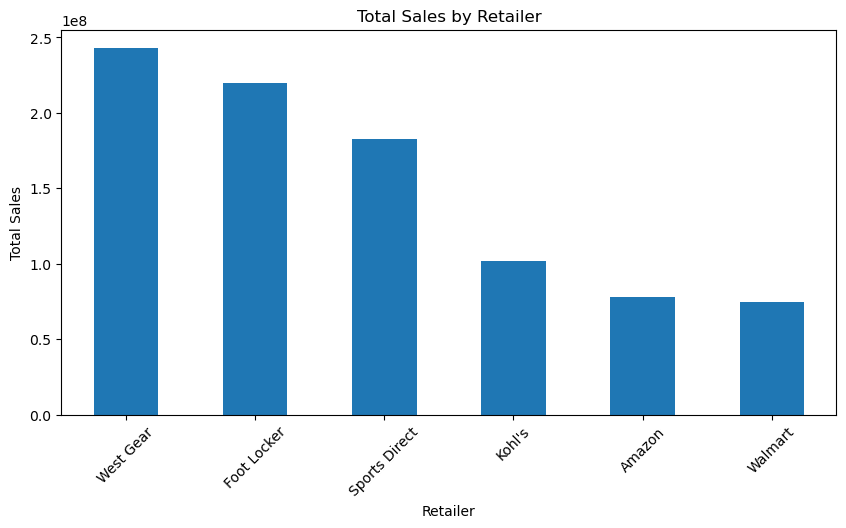

In [242]:
plt.figure(figsize=(10, 5))
retailer_summary["Total Sales"].plot(kind="bar")
plt.title("Total Sales by Retailer")
plt.xlabel("Retailer")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

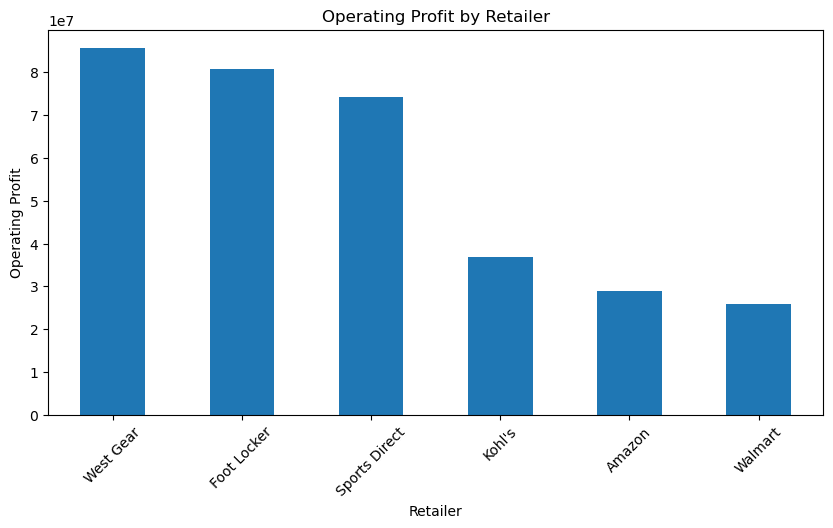

In [243]:
plt.figure(figsize=(10, 5))
retailer_summary["Operating Profit"].plot(kind="bar")
plt.title("Operating Profit by Retailer")
plt.xlabel("Retailer")
plt.ylabel("Operating Profit")
plt.xticks(rotation=45)
plt.show()##利润图

In [244]:
retailer_summary["Profit Margin"] = retailer_summary["Operating Profit"] / retailer_summary["Total Sales"]

retailer_summary.sort_values(by="Profit Margin", ascending=False)

,Total Sales,Units Sold,Operating Profit,Profit Margin
Retailer,,,,
Sports Direct,182470997.0,557640,74332954.96,0.407369
Amazon,77698912.0,197990,28818503.31,0.370900
Foot Locker,220094720.0,604369,80722124.81,0.366761
Kohl's,102114753.0,287375,36811252.58,0.360489
West Gear,242964333.0,625262,85667873.18,0.352594
Walmart,74558410.0,206225,25782052.61,0.345797


### 零售商表现分析结论

从 Retailer 维度来看，West Gear 是销售额最高的零售商，总销售额约为 2.43 亿美元，销量约为 62.5 万件，营业利润约为 8,567 万美元，是 Adidas 的核心合作渠道之一。

Foot Locker 销售额排名第二，约为 2.20 亿美元，营业利润约为 8,072 万美元，同样具有较高的销售贡献。Sports Direct 虽然销售额低于 West Gear 和 Foot Locker，但利润率最高，约为 40.74%，说明其盈利效率较强。

从渠道合作策略来看，West Gear 和 Foot Locker 适合承担重点销售任务，可以优先获得新品铺货和促销资源；Sports Direct 则值得关注其高利润率表现，进一步分析其产品结构和定价策略，寻找可复制的经营经验。

## 6. 时间趋势分析

本节基于 Invoice Date 分析销售额随时间变化的趋势，观察销售高峰和低谷，为促销排期、备货计划和经营节奏提供参考。

In [247]:
data["Month"] = data["Invoice Date"].dt.to_period("M")

monthly_sales = data.groupby("Month")[["Total Sales", "Operating Profit", "Units Sold"]].sum()

monthly_sales

,Total Sales,Operating Profit,Units Sold
Month,,,
2020-01,16253746.0,5830005.41,48333
2020-02,14997988.0,5207354.44,37846
2020-03,17660577.0,5862006.26,46972
2020-04,24607006.0,9301293.34,54709
2020-05,16918014.0,5870841.95,35705
2020-06,8829819.0,2292727.41,16269
2020-07,17146013.0,4917665.11,38219
2020-08,19877980.0,7338924.54,62307
2020-09,18304436.0,7119702.44,46125


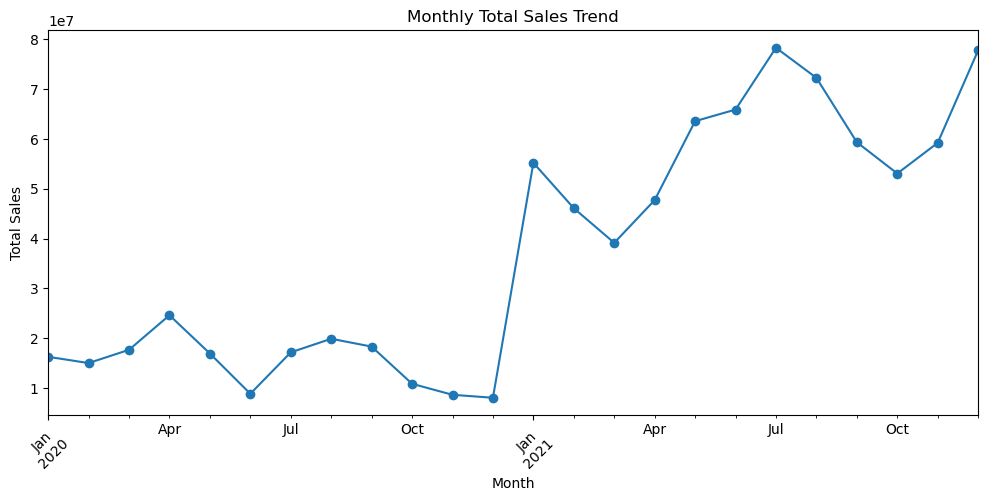

In [248]:
plt.figure(figsize=(12, 5))
monthly_sales["Total Sales"].plot(marker="o")
plt.title("Monthly Total Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()##销售图

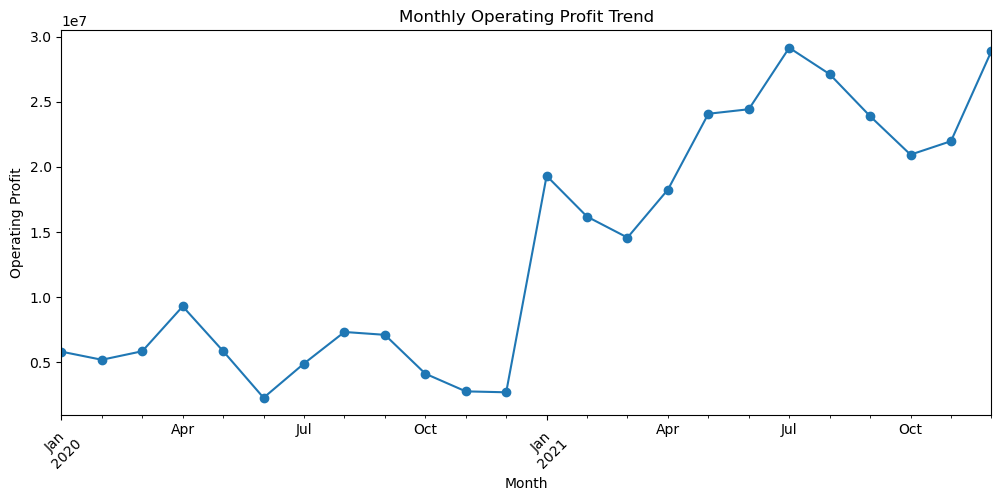

In [249]:
plt.figure(figsize=(12, 5))
monthly_sales["Operating Profit"].plot(marker="o")
plt.title("Monthly Operating Profit Trend")
plt.xlabel("Month")
plt.ylabel("Operating Profit")
plt.xticks(rotation=45)
plt.show()##利润图

### 时间趋势分析结论

从月度趋势来看，销售额和营业利润随时间呈现一定波动。销售高峰月份可能与促销活动、季节性需求或渠道活动有关，企业可以在销售高峰前提前进行库存准备和营销规划。

对于销售低谷月份，可以通过促销活动、产品组合调整或区域市场推广来提升销售表现。该分析对供应链补货、采销计划和经营节奏安排具有参考价值。

## 7. 产品与渠道交叉分析

本节将 Product 与 Sales Method 结合起来，分析不同产品在不同销售渠道中的表现，判断哪些产品更适合线上销售，哪些产品更适合线下门店或 Outlet 渠道。

In [252]:
product_channel_sales = data.pivot_table(
    index="Product",
    columns="Sales Method",
    values="Total Sales",
    aggfunc="sum"
)

product_channel_sales

Sales Method,In-store,Online,Outlet
Product,,,
Men's Apparel,49325000.0,35528995.0,38874637.0
Men's Athletic Footwear,59348750.0,41715609.0,52609321.0
Men's Street Footwear,88852000.0,56844308.0,63129936.0
Women's Apparel,70248750.0,49763155.0,59026955.0
Women's Athletic Footwear,40520000.0,29593467.0,36518429.0
Women's Street Footwear,48349250.0,34227348.0,45426215.0


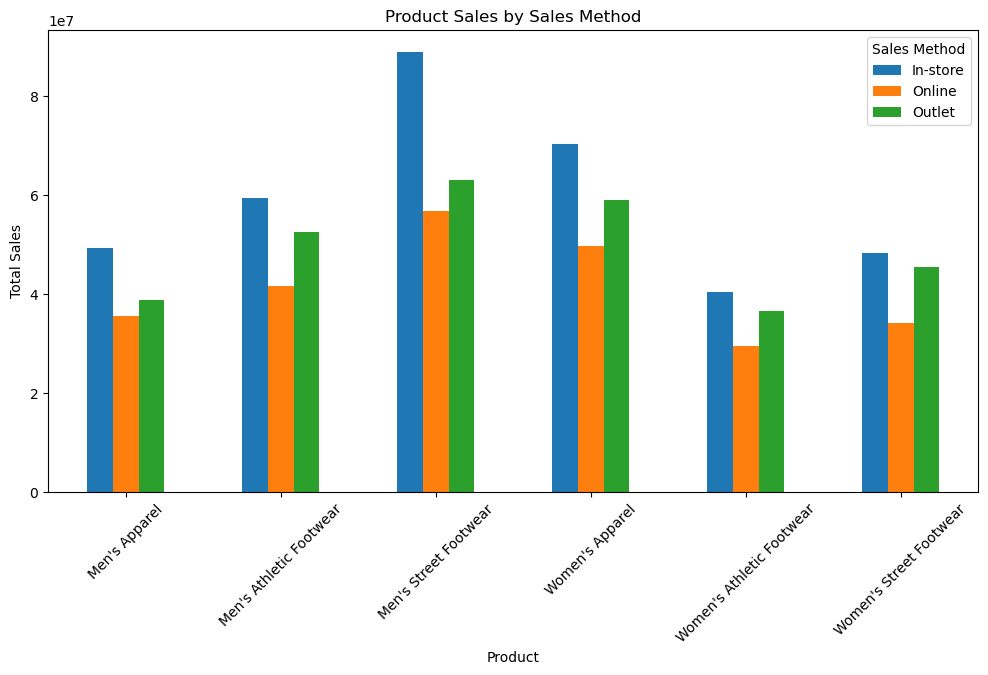

In [253]:
product_channel_sales.plot(kind="bar", figsize=(12, 6))

plt.title("Product Sales by Sales Method")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

In [254]:
product_channel_profit = data.pivot_table(
    index="Product",
    columns="Sales Method",
    values="Operating Profit",
    aggfunc="sum"
)

product_channel_profit##利润 版本

Sales Method,In-store,Online,Outlet
Product,,,
Men's Apparel,17474500.0,12827852.21,14460678.12
Men's Athletic Footwear,19702375.0,15674177.79,16470335.40
Men's Street Footwear,34867100.0,22958021.76,24977138.86
Women's Apparel,26285125.0,20843599.33,21522246.23
Women's Athletic Footwear,13568625.0,11540214.63,13866945.31
Women's Street Footwear,15693562.5,12711310.75,16690953.56


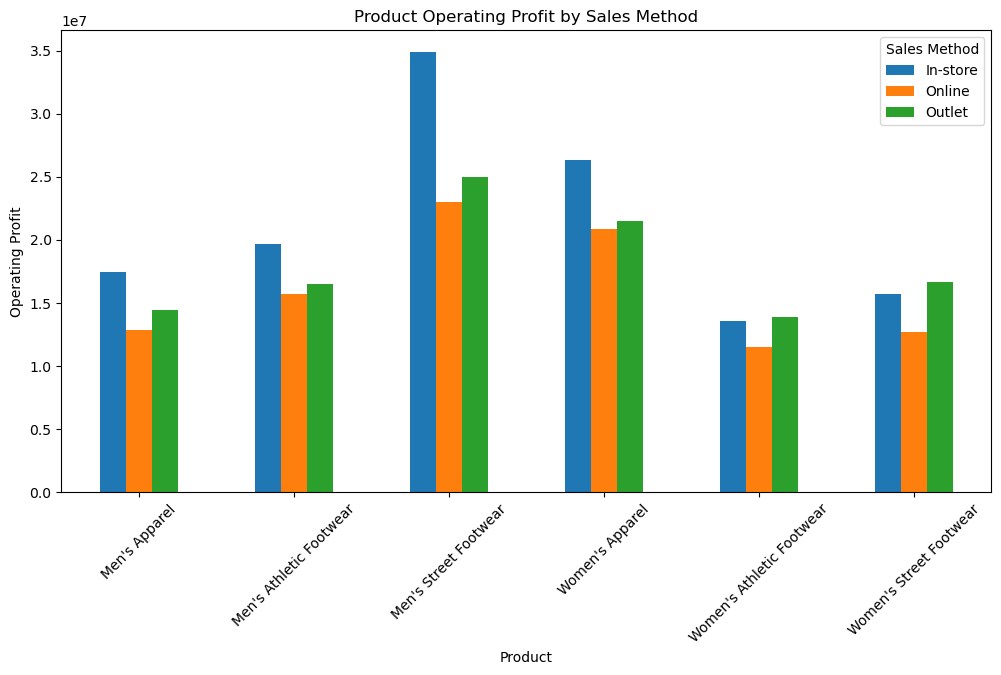

In [255]:
product_channel_profit.plot(kind="bar", figsize=(12, 6))

plt.title("Product Operating Profit by Sales Method")
plt.xlabel("Product")
plt.ylabel("Operating Profit")
plt.xticks(rotation=45)
plt.show()

### 产品与渠道交叉分析结论

通过将 Product 与 Sales Method 结合分析，可以进一步判断不同产品在不同渠道中的销售表现。相比单独分析产品或渠道，交叉分析更接近真实经营决策场景。

如果某类产品在线上渠道表现较好，说明该产品适合通过数字化营销、平台推荐和会员运营进行推广；如果某类产品在线下门店表现更好，则说明消费者可能更依赖试穿、体验和门店服务。

对于采销和供应链管理而言，产品与渠道交叉分析可以帮助企业制定更细的补货策略，例如将高销量产品优先分配到强势渠道，将高利润产品安排在转化效率更高的渠道中，从而提升整体经营效率。

## 8. 区域与产品交叉分析

本节将 Region 与 Product 结合起来，分析不同地区对不同产品类别的需求差异，为区域备货、产品组合和采销计划提供参考。

In [258]:
region_product_sales = data.pivot_table(
    index="Region",
    columns="Product",
    values="Total Sales",
    aggfunc="sum"
)

region_product_sales

Product,Men's Apparel,Men's Athletic Footwear,Men's Street Footwear,Women's Apparel,Women's Athletic Footwear,Women's Street Footwear
Region,,,,,,
Midwest,18125661.0,21305539.0,38322810.0,28206383.0,13595168.0,16244898.0
Northeast,25744412.0,28874237.0,51025024.0,37543083.0,19796138.0,23341173.0
South,19703069.0,25710545.0,28444561.0,29607187.0,18420722.0,22777097.0
Southeast,24461487.0,27777020.0,36019236.0,31491161.0,20302798.0,23119534.0
West,35694003.0,50006339.0,55014613.0,52191046.0,34517070.0,42520111.0


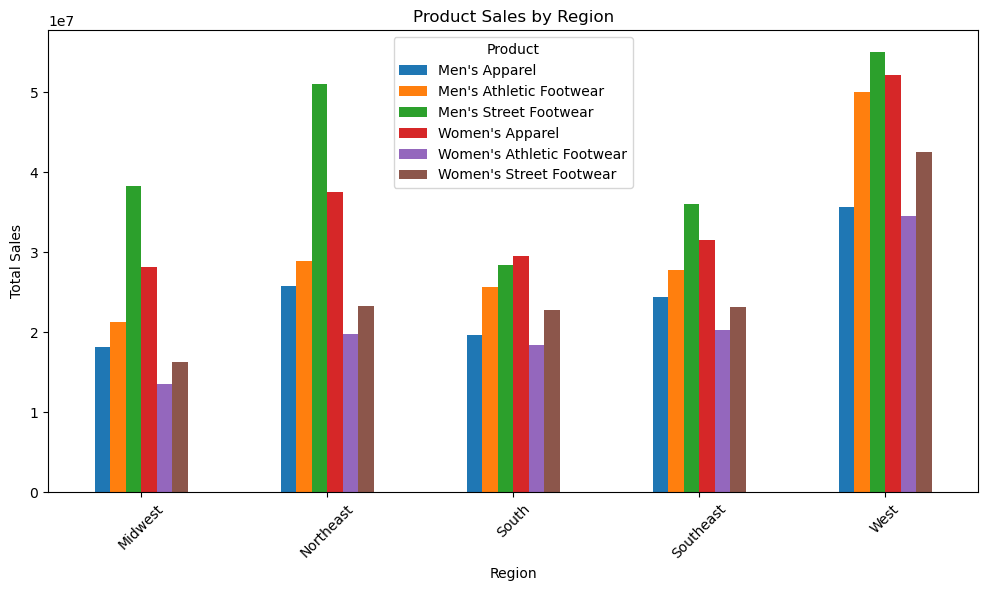

In [259]:
region_product_sales.plot(kind="bar", figsize=(12, 6))

plt.title("Product Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

### 区域与产品交叉分析结论

通过 Region 与 Product 的交叉分析，可以观察不同地区对产品类别的需求差异。某些地区可能更偏好鞋类产品，而另一些地区则可能在服饰类产品上表现更好。

这类分析对供应链和采销岗位非常重要。企业可以根据不同区域的产品需求差异进行差异化备货，避免所有地区采用相同的库存结构。对于销售额较高的地区，应优先保障主力产品库存；对于销售额较低但某些产品表现较好的地区，可以通过局部重点投放来提升增长。

## 13. 综合业务洞察

基于前文对地区、城市、产品、渠道、零售商、时间趋势以及交叉维度的分析，本节对 Adidas 美国市场销售表现进行综合总结，提炼核心发现，为经营分析、采销管理和供应链补货提供参考。

In [283]:
top_region = region_summary["Total Sales"].idxmax()
top_state = state_sales.idxmax()
top_city = city_sales.idxmax()
top_product = product_summary["Total Sales"].idxmax()
top_profit_product = product_summary["Operating Profit"].idxmax()
top_channel = channel_summary["Total Sales"].idxmax()
top_retailer = retailer_summary["Total Sales"].idxmax()

print("Top Region:", top_region)
print("Top State:", top_state)
print("Top City:", top_city)
print("Top Product by Sales:", top_product)
print("Top Product by Profit:", top_profit_product)
print("Top Sales Method:", top_channel)
print("Top Retailer:", top_retailer)

Top Region: West
Top State: New York
Top City: Charleston
Top Product by Sales: Men's Street Footwear
Top Product by Profit: Men's Street Footwear
Top Sales Method: In-store
Top Retailer: West Gear


## 13. 综合业务洞察

基于前面的分析，可以总结出以下核心发现：

1. **区域表现**：West 区销售额最高，Midwest 最低，说明 West 是核心市场，Midwest 仍有增长空间。
2. **城市表现**：某些大城市（例如 New York、Los Angeles 等）贡献主要销售额，核心城市应优先库存保障和营销投放。
3. **产品表现**：Men's Street Footwear 是主力产品，同时利润率最高，应重点维护库存与推广；Women's Apparel 是重要增长产品。
4. **渠道表现**：In-store 销售额最高，Online 渠道销量和利润率高，未来可以线上重点推广高利润产品。
5. **零售商表现**：West Gear 和 Foot Locker 是核心合作零售商，Sports Direct 虽销售额中等但利润率高。
6. **时间趋势**：2021 年销售明显高于 2020 年，7 月和 12 月为销售高峰月份，低谷月份可结合促销优化。
7. **交叉分析**：
   - 产品 × 渠道：某些产品适合线上，某些适合线下/Outlet。
   - 区域 × 产品：不同区域产品需求差异明显，有利于精准备货与补货。

## 14. 经营建议总结

基于前文对地区、城市、产品、渠道、零售商、时间趋势以及交叉分析的综合洞察，本项目提出以下经营与采销策略建议：

1. **核心区域策略**
   - West 区销售额最高，应优先保障库存和营销资源，避免断货影响销售。
   - Midwest 等低销售区域需优化产品组合与渠道布局，提高市场渗透率。

2. **产品策略**
   - Men's Street Footwear 为主力产品且利润率最高，应保持稳定库存，并在高销售地区和高利润渠道重点推广。
   - Women's Apparel 为重要增长产品，可作为战略产品加大营销投入。
   - 对销量高但利润率低的产品，考虑优化定价、促销策略或成本控制。

3. **渠道优化**
   - In-store 渠道销售额最高，适合作为品牌展示和主要销售渠道。
   - Online 渠道销量高且利润率最佳，可进一步加大投入，高利润产品优先推广。
   - Outlet 渠道销售额和利润稳定，可作为辅助渠道优化库存分配。

4. **零售商管理**
   - 核心零售商（如 West Gear、Foot Locker）应优先进行新品铺货、促销联动及库存保障。
   - 高利润零售商（如 Sports Direct）可重点研究其产品组合和定价策略，复制成功经验。
   - 对表现中等或低利润零售商，评估合作策略和库存分配优化空间。

5. **时间与库存管理**
   - 销售高峰月份（如 2021-07 和 2021-12）需提前备货，并结合重点产品和渠道加大营销资源投入。
   - 销售低谷月份可通过促销活动、区域市场推广和产品组合调整提升销售表现。
   - 建议根据月度和季度销售预测优化库存周转，降低滞销风险。

6. **交叉维度策略**
   - 产品 × 渠道：将高销量高利润产品优先分配到最适合的渠道，提高整体盈利效率。
   - 区域 × 产品：根据不同区域的产品需求差异进行差异化备货，提高库存使用效率和市场响应速度。

> 总结：通过以上策略，Adidas 美国市场可以实现库存优化、渠道精细化管理、产品组合合理化，并提升整体营业额和利润率，同时为经营决策提供量化依据。

## 15. 项目总结

本项目基于 Kaggle 公开的 Adidas 美国销售数据集，使用 Python Pandas 和 Matplotlib 对销售数据进行了系统分析，从多个维度为经营决策提供支持：

1. **数据处理与探索**  
   - 对销售数据进行了读取、清洗、缺失值和重复值检查，确保数据完整性和准确性。
   - 对各字段进行了类型转换和统计概览，为后续分析奠定基础。

2. **单维度分析**  
   - 分析了地区、州、城市、产品、渠道、零售商和时间趋势的销售表现。
   - 识别出核心区域、主力产品、关键渠道和核心零售商。

3. **交叉维度分析**  
   - 产品 × 渠道分析发现了不同产品在不同销售渠道的表现差异，为渠道策略和产品分配提供依据。
   - 区域 × 产品分析揭示了不同地区对产品类别的需求差异，有助于优化库存和采销计划。

4. **综合业务洞察**  
   - 整合各维度分析结果，提炼关键发现，为经营策略提供量化依据。
   - 包括高价值市场识别、核心产品及渠道配置、零售商策略、时间趋势优化等。

5. **经营策略建议**  
   - 提出库存优化、渠道资源配置、产品组合管理和促销策略等可落地建议。
   - 为经营分析、战略决策、供应链管理和采销计划提供参考。

**项目价值**  
- 展示了完整的数据分析流程，从数据获取到清洗、分析、可视化再到商业洞察与策略建议。
- 能够将销售数据转化为实际经营决策的参考，体现商业分析能力。
- 结构清晰、逻辑完整，适合在简历中展示，也便于面试中讲解。

> 总结：本项目不仅展示了数据分析技能，也体现了将分析结果应用于实际经营决策的能力，适合用于经营分析、战略分析和供应链/采销岗位的作品集展示。

## 8. 经营建议总结

基于本项目分析结果，可以得到以下经营建议：

1. **区域经营方面**  
   对销售额较高的 Region、State 和 City，应优先保障库存供应和营销资源，避免核心市场因缺货影响销售转化。

2. **产品策略方面**  
   对销售额高的主力产品，应保持稳定供应；对利润率高的产品，可以增加推广力度，提高整体盈利能力。

3. **渠道策略方面**  
   不同 Sales Method 的销售额和利润率存在差异。企业应根据渠道表现优化资源配置，避免只追求销售额而忽视利润表现。

4. **零售商合作方面**  
   对销售贡献较高的 Retailer，可以加强合作关系，包括新品首发、联合促销和重点库存支持。对利润率较低的零售商，需要进一步评估折扣政策和成本结构。

5. **供应链与采销方面**  
   销售高峰月份前应提前备货，重点关注核心区域、核心产品和核心零售商，提升库存周转效率，降低滞销和缺货风险。

# 项目总结

本项目基于 Kaggle 公开 Adidas 美国销售数据，使用 Python Pandas 和 Matplotlib 完成了数据读取、清洗、分组汇总、可视化分析和业务洞察总结。

通过对地区、城市、产品、渠道、零售商和时间趋势的分析，项目识别了 Adidas 在美国市场中的核心销售区域、重点产品、主要渠道和核心零售商，并进一步提出了面向经营分析、采销管理和供应链补货的优化建议。

本项目展示了基础数据分析流程，也体现了如何将销售数据转化为经营决策参考。

In [264]:
from IPython.display import display

display(region_summary)
display(product_summary)
display(channel_summary)
display(retailer_summary)x
display(monthly_sales)

,Total Sales,Units Sold,Operating Profit
Region,,,
West,269943182.0,686985,89609406.55
Northeast,186324067.0,501279,68020587.65
Southeast,163171236.0,407000,60555416.70
South,144663181.0,492260,61138004.07
Midwest,135800459.0,391337,52811346.48


,Total Sales,Units Sold,Operating Profit
Product,,,
Men's Street Footwear,208826244.0,593320,82802260.62
Women's Apparel,179038860.0,433827,68650970.56
Men's Athletic Footwear,153673680.0,435526,51846888.19
Women's Street Footwear,128002813.0,392269,45095826.81
Men's Apparel,123728632.0,306683,44763030.33
Women's Athletic Footwear,106631896.0,317236,38975784.94


,Total Sales,Operating Profit
Sales Method,,
In-store,356643750.0,1.275913e+08
Online,247672882.0,9.655518e+07
Outlet,295585493.0,1.079883e+08


,Total Sales,Units Sold,Operating Profit,Profit Margin
Retailer,,,,
West Gear,242964333.0,625262,85667873.18,0.352594
Foot Locker,220094720.0,604369,80722124.81,0.366761
Sports Direct,182470997.0,557640,74332954.96,0.407369
Kohl's,102114753.0,287375,36811252.58,0.360489
Amazon,77698912.0,197990,28818503.31,0.370900
Walmart,74558410.0,206225,25782052.61,0.345797


,Total Sales,Operating Profit,Units Sold
Month,,,
2020-01,16253746.0,5830005.41,48333
2020-02,14997988.0,5207354.44,37846
2020-03,17660577.0,5862006.26,46972
2020-04,24607006.0,9301293.34,54709
2020-05,16918014.0,5870841.95,35705
2020-06,8829819.0,2292727.41,16269
2020-07,17146013.0,4917665.11,38219
2020-08,19877980.0,7338924.54,62307
2020-09,18304436.0,7119702.44,46125


### 时间趋势分析结论

从月度销售趋势来看，2021 年 Adidas 美国市场销售表现明显强于 2020 年。2020 年整体销售额相对较低，销售高峰出现在 2020 年 4 月，约为 2,461 万美元；而 2021 年多个单月销售额超过 5,000 万美元，说明销售规模在 2021 年出现明显增长。

其中，2021 年 7 月销售额最高，约为 7,833 万美元；2021 年 12 月销售额也达到约 7,781 万美元，说明年中和年末可能是 Adidas 销售表现较强的阶段。企业可以在销售高峰前提前进行库存准备，并加强重点产品和核心渠道的资源投入。

相比之下，2020 年 6 月、11 月和12 月销售额较低，说明部分月份存在销售低谷。企业可以通过促销活动、渠道投放和产品组合调整来提升低谷月份表现。

In [266]:
monthly_sales = monthly_sales.reset_index()
monthly_sales["Month"] = monthly_sales["Month"].astype(str)

monthly_sales

,Month,Total Sales,Operating Profit,Units Sold
0,2020-01,16253746.0,5830005.41,48333
1,2020-02,14997988.0,5207354.44,37846
2,2020-03,17660577.0,5862006.26,46972
3,2020-04,24607006.0,9301293.34,54709
4,2020-05,16918014.0,5870841.95,35705
5,2020-06,8829819.0,2292727.41,16269
6,2020-07,17146013.0,4917665.11,38219
7,2020-08,19877980.0,7338924.54,62307
8,2020-09,18304436.0,7119702.44,46125
9,2020-10,10836269.0,4139469.21,30167


In [155]:
monthly_sales["Year"] = monthly_sales["Month"].str[:4]
monthly_sales["Month_Num"] = monthly_sales["Month"].str[5:7]

monthly_sales.head()

,Month,Total Sales,Operating Profit,Units Sold,Year,Month_Num
0,2020-01,16253746.0,5830005.41,48333,2020,01
1,2020-02,14997988.0,5207354.44,37846,2020,02
2,2020-03,17660577.0,5862006.26,46972,2020,03
3,2020-04,24607006.0,9301293.34,54709,2020,04
4,2020-05,16918014.0,5870841.95,35705,2020,05


In [157]:
year_month_sales = monthly_sales.pivot(
    index="Month_Num",
    columns="Year",
    values="Total Sales"
)

year_month_sales##2020vs2021

Year,2020,2021
Month_Num,,
01,16253746.0,55225396.0
02,14997988.0,46102165.0
03,17660577.0,39148532.0
04,24607006.0,47732964.0
05,16918014.0,63589681.0
06,8829819.0,65917553.0
07,17146013.0,78334681.0
08,19877980.0,72288221.0
09,18304436.0,59357023.0


In [159]:
year_month_sales["YoY Growth"] = (
    year_month_sales["2021"] - year_month_sales["2020"]
) / year_month_sales["2020"]

year_month_sales##算同比增长率

Year,2020,2021,YoY Growth
Month_Num,,,
01,16253746.0,55225396.0,2.397703
02,14997988.0,46102165.0,2.073890
03,17660577.0,39148532.0,1.216719
04,24607006.0,47732964.0,0.939812
05,16918014.0,63589681.0,2.758697
06,8829819.0,65917553.0,6.465335
07,17146013.0,78334681.0,3.568682
08,19877980.0,72288221.0,2.636598
09,18304436.0,59357023.0,2.242767


<Figure size 1000x500 with 0 Axes>

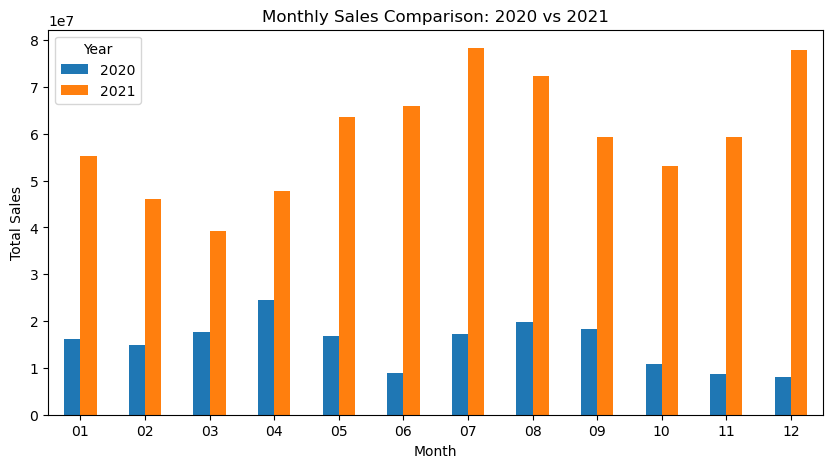

In [161]:
plt.figure(figsize=(10, 5))
year_month_sales[["2020", "2021"]].plot(kind="bar", figsize=(10, 5))
plt.title("Monthly Sales Comparison: 2020 vs 2021")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.show()

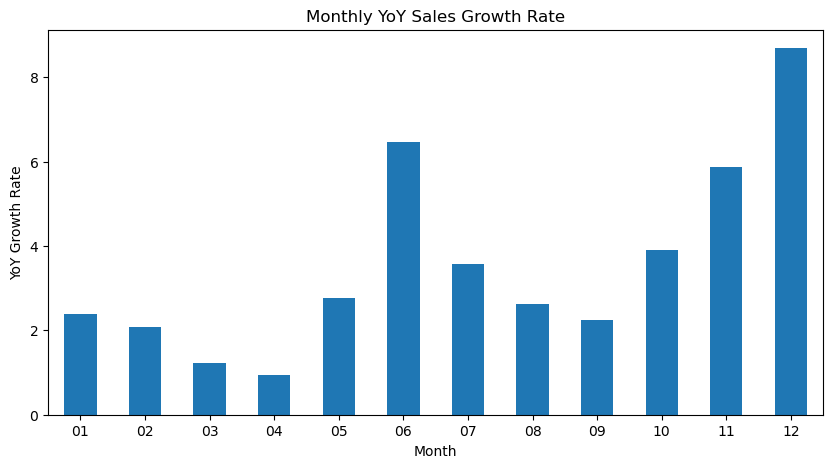

In [163]:
plt.figure(figsize=(10, 5))
year_month_sales["YoY Growth"].plot(kind="bar")
plt.title("Monthly YoY Sales Growth Rate")
plt.xlabel("Month")
plt.ylabel("YoY Growth Rate")
plt.xticks(rotation=0)
plt.show()

### 同比分析结论

通过对 2020 年和 2021 年各月份销售额进行对比可以看出，2021 年 Adidas 美国市场销售额整体明显高于 2020 年，多个月份实现大幅增长。这说明品牌在 2021 年的市场恢复、渠道拓展或销售执行方面可能表现更好。

从经营角度看，同比增长较高的月份值得重点复盘，分析其背后的产品、渠道和零售商贡献；同比增长较低的月份则需要关注是否存在库存不足、渠道转化弱或市场推广不足的问题。